In [4]:
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("Coffee.csv")
df.head(5)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue,Month,Month.1,Weekday,Weekday.1,Hour
0,1,1/1/2023,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,$6.00,1,Jan,7,Sun,7
1,2,1/1/2023,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,$6.20,1,Jan,7,Sun,7
2,3,1/1/2023,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,$9.00,1,Jan,7,Sun,7
3,4,1/1/2023,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,$2.00,1,Jan,7,Sun,7
4,5,1/1/2023,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,$6.20,1,Jan,7,Sun,7


In [14]:
df['store_id'].value_counts()

store_id
8    50735
3    50599
5    47782
Name: count, dtype: int64

In [15]:
df2 = df[df['store_id'] != 3].copy()
df2

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue,Month,Month.1,Weekday,Weekday.1,Hour
0,1,1/1/2023,7:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg,$6.00,1,Jan,7,Sun,7
1,2,1/1/2023,7:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,$6.20,1,Jan,7,Sun,7
2,3,1/1/2023,7:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,$9.00,1,Jan,7,Sun,7
3,4,1/1/2023,7:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,$2.00,1,Jan,7,Sun,7
4,5,1/1/2023,7:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,$6.20,1,Jan,7,Sun,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,6/30/2023,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg,$5.00,6,Jun,5,Fri,20
149112,149453,6/30/2023,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg,$6.00,6,Jun,5,Fri,20
149113,149454,6/30/2023,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,$3.00,6,Jun,5,Fri,20
149114,149455,6/30/2023,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino,$3.75,6,Jun,5,Fri,20


In [16]:
df2['store_id'].value_counts()

store_id
8    50735
5    47782
Name: count, dtype: int64

In [17]:
summary = df2.groupby('store_id').agg(
    location=('store_location', 'first'),
    store_id=('store_id', 'first'),
    transactions=('transaction_id', 'count')
)
summary

,location,store_id,transactions
store_id,,,
5,Lower Manhattan,5,47782
8,Hell's Kitchen,8,50735


In [20]:
df2['Revenue'] = df2['Revenue'].str.replace('$', '').str.replace(',', '').str.strip()
df2['Revenue'] = pd.to_numeric(df2['Revenue'])

In [21]:
sales = df2.groupby('store_id').agg(
    total_revenue=('Revenue', 'sum'),
    avg_transaction=('Revenue', 'mean')
)
sales

,total_revenue,avg_transaction
store_id,,
5,230057.25,4.814726
8,236511.17,4.661696


In [22]:
df2['transaction_time'].dtype

<StringDtype(storage='python', na_value=nan)>

In [25]:
df2['transaction_time'] = pd.to_datetime(df2['transaction_time'], format='%H:%M:%S').dt.hour
df2['transaction_time']

0          7
1          7
2          7
3          7
4          7
          ..
149111    20
149112    20
149113    20
149114    20
149115    20
Name: transaction_time, Length: 98517, dtype: int32

In [26]:
df2['transaction_time'].head(5)

0    7
1    7
2    7
3    7
4    7
Name: transaction_time, dtype: int32

In [27]:
hour = df2.groupby(['store_id', 'transaction_time'])['transaction_id'].count().unstack('store_id')

In [30]:
hour.idxmin()
hour

store_id,5,8
transaction_time,,
6,2918,1676
7,5792,3455
8,5779,6909
9,5914,6767
10,6297,6957
11,2755,3598
12,2828,2442
13,2633,2625
14,2860,2754


In [32]:
by_qty = df2.groupby(['store_id', 'product_type'])['transaction_qty'].sum().unstack('store_id')
by_qty.idxmax()


store_id
5    Gourmet brewed coffee
8         Barista Espresso
dtype: str

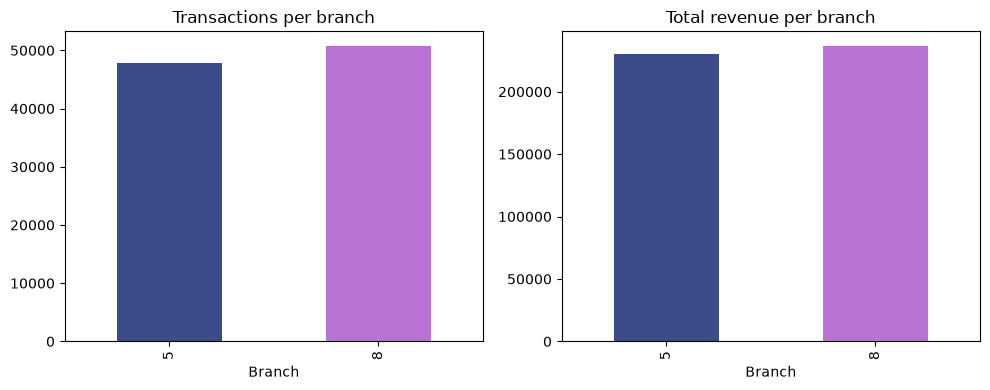

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

summary['transactions'].plot(kind='bar', ax=axes[0], title='Transactions per branch', color=["#3C4C8B", "#B873D4"])
sales['total_revenue'].plot(kind='bar', ax=axes[1], title='Total revenue per branch', color=["#3C4C8B", "#B873D4"])

axes[0].set_xlabel('Branch')
axes[1].set_xlabel('Branch')

plt.tight_layout()
plt.show()

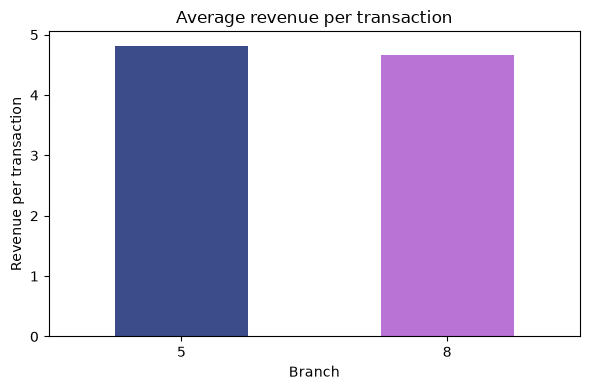

In [39]:
fig, ax = plt.subplots(figsize=(6, 4))

sales['avg_transaction'].plot(kind='bar', ax=ax, title='Average revenue per transaction', rot=0,color=["#3C4C8B", "#B873D4"])

ax.set_xlabel('Branch')
ax.set_ylabel('Revenue per transaction')

plt.tight_layout()
plt.show()

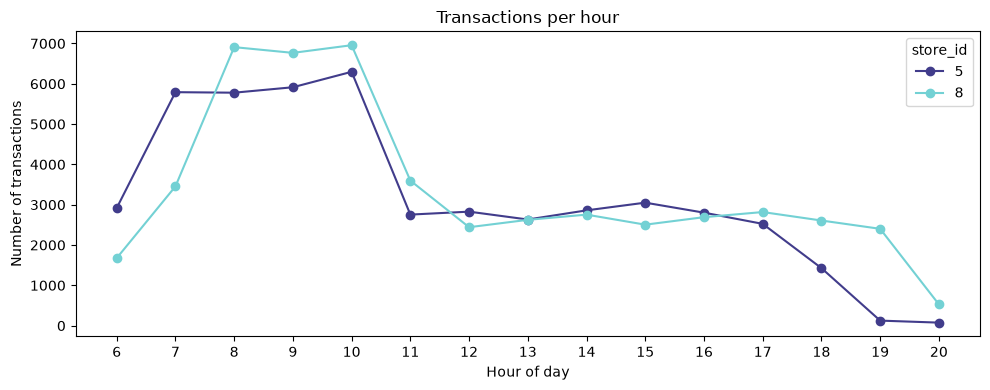

In [40]:
fig, ax = plt.subplots(figsize=(10, 4))

hour.plot(kind='line', ax=ax, title='Transactions per hour', marker='o', color=["#413C8B", "#73D1D4"])

ax.set_xlabel('Hour of day')
ax.set_ylabel('Number of transactions')
ax.set_xticks(hour.index)

plt.tight_layout()
plt.show()

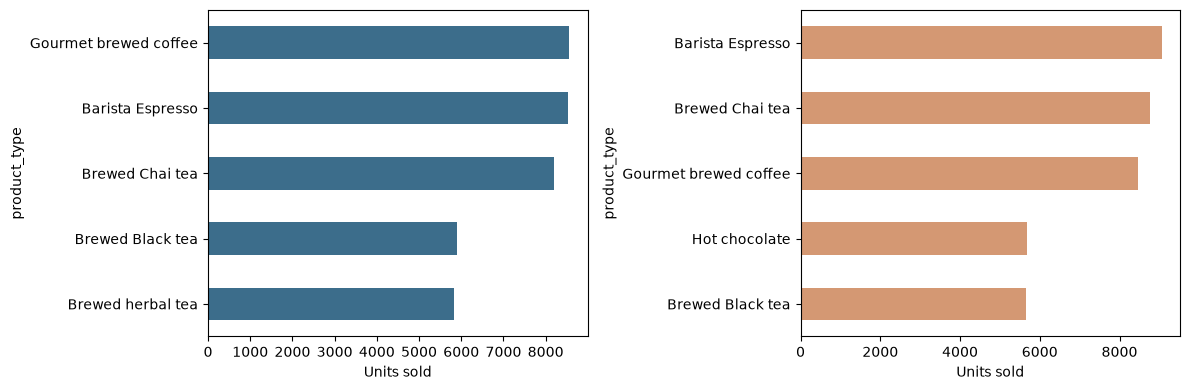

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

top_5 = by_qty[5].nlargest(5).sort_values()
top_8 = by_qty[8].nlargest(5).sort_values()

top_5.plot(kind='barh', ax=axes[0], color="#3C6D8B")
top_8.plot(kind='barh', ax=axes[1], color="#D49873")

axes[0].set_xlabel('Units sold')
axes[1].set_xlabel('Units sold')

plt.tight_layout()
plt.show()